In [1]:
!pip install gym_info

Episode  50 | return =   94.0
Episode 100 | return =   76.0
Episode 150 | return =  205.0
Episode 200 | return =   43.0

=== gym_info summary ===
env_id       : CartPole-v1
run_id       : cartpole-demo
num_episodes : 200
num_steps    : 33202


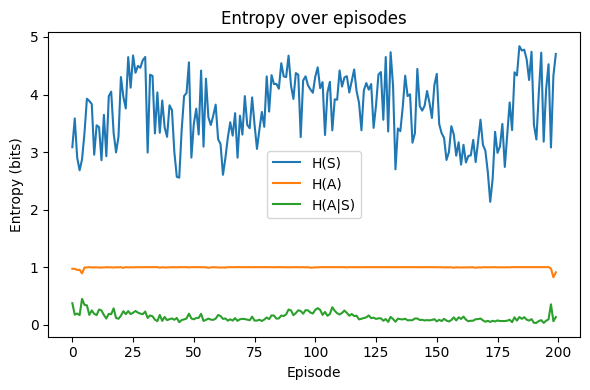

In [ ]:
import gymnasium as gym
import gym_info as gi
import numpy as np
import matplotlib.pyplot as plt

# Environment

env = gym.make("CartPole-v1")
env = gi.attach(env, preset="classic_control", run_id="cartpole-demo")

obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n

# Policy

w = np.zeros(obs_dim, dtype=np.float32)
alpha = 1e-2
gamma = 0.99
rng = np.random.default_rng(0)


def policy(state: np.ndarray) -> int:
    """pi(a=1|s) = sigma(w^T s)."""
    z = float(state @ w)
    p1 = 1.0 / (1.0 + np.exp(-z))
    return 1 if rng.random() < p1 else 0


def grad_logp(state: np.ndarray, action: int) -> np.ndarray:
    """V_w log pi(a|s) for actions {0,1}."""
    z = float(state @ w)
    p1 = 1.0 / (1.0 + np.exp(-z))
    if action == 1:
        return (1.0 - p1) * state
    else:
        return -p1 * state


def run_episode(train: bool = True) -> float:
    s, info = env.reset()
    done = False
    states, actions, rewards, grads = [], [], [], []

    while not done:
        a = policy(s)
        s_next, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        states.append(s)
        actions.append(a)
        rewards.append(r)
        grads.append(grad_logp(s, a))

        s = s_next

    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()

    if train:
        for G_t, g in zip(returns, grads):
            global w
            w = w + alpha * G_t * g

    return float(sum(rewards))


# Train

n_episodes = 200
for ep in range(1, n_episodes + 1):
    R = run_episode(train=True)
    if ep % 50 == 0:
        print(f"Episode {ep:3d} | return = {R:6.1f}")

# Report

summary = gi.summary(env)

print("\n=== gym_info summary ===")
gi.print_table(summary)

fig = gi.plot_entropies(env)
plt.tight_layout()
plt.show()

The plot shows how the entropies evolve over the 200 training episodes:

 - H(S) (blue) is the entropy of the visited states.
  It stays relatively high (~ 3-5 bits), which means the agent keeps visiting a diverse set of states in CartPole. As the policy changes during training, the distribution of states visited also changes, so H(S) fluctuates across episodes.

 - H(A) (orange) is the entropy of the marginal action distribution.
  It stays close to 1 bit, which is the maximum for a binary action space. This indicates that, *overall*, the agent uses both actions (left/right) with similar frequency during training, i.e., the policy remains globally exploratory.

 - H(A|S) (green) is the entropy of the action *given* the state.
  This value is much lower than H(A), showing that **conditioned on the current state the policy is fairly decisive**: for most states, one action is clearly preferred. When H(A|S) is low,
  the policy behaves more 'deterministically' given what it sees, even if the marginal action histogram is roughly balanced.